In [1]:
import pandas as pd
from net2rank.utils import H5Loader
import gzip
import matplotlib.pyplot as plt

embedding_file = 'data/9606.node2vec64.h5'
human_embeddings = H5Loader(embedding_file)
protein_space = human_embeddings.proteins

colors = ['#76c1bd', '#fad9bd', '#6ba6ff', '#f8eecb']
disease2color = {
    'atopic_dermatitis': colors[0],
    'ulcerative_colitis': colors[0],
    'focal_epilepsy': colors[1],
    'colorectal_adenocarcinoma': colors[2],
    'melanoma': colors[2],
    'diffuse_large_b-cell_lymphoma': colors[2],
    'aortic_aneurysm': colors[3]
}

all_positives = set()
for disease in disease2color.keys():
    file = f'data/test/{disease}.gold_standard.balanced.tsv'
    df_gold_standard = pd.read_csv(file, sep='\t', header=None)
    pos_proteins = df_gold_standard[df_gold_standard.iloc[:,1] == 1].iloc[:,0]
    all_positives.update(pos_proteins)

In [2]:
## median value of STRING
no_text_scores = dict()
print('Doing no text scores...')
with open('data/9606.protein.link.no_text.v12.0.txt','r') as f:
    for line in f:
        protein1, protein2, score = line.strip().split()
        score = int(score) / 1000
        
        if protein1 in all_positives:
            if protein1 in no_text_scores:
                no_text_scores[protein1].append(score)
            else:
                no_text_scores[protein1] = [score]
                
        if protein2 in all_positives:
            if protein2 in no_text_scores:
                no_text_scores[protein2].append(score)
            else:
                no_text_scores[protein2] = [score]
        
combined_scores = dict()
print('Doing combined scores...')
with gzip.open('data/9606.protein.links.full.v12.0.txt.gz','rb') as f:
    for idx, line in enumerate(f):
        if idx == 0: continue
        line = line.decode('utf-8').strip().split()
        protein1 = line[0]
        protein2 = line[1]
        score = line[-1]
        score = int(score) / 1000
        
        if protein1 in all_positives:
            if protein1 in combined_scores:
                combined_scores[protein1].append(score)
            else:
                combined_scores[protein1] = [score]
                
        if protein2 in all_positives:
            if protein2 in combined_scores:
                combined_scores[protein2].append(score)
            else:
                combined_scores[protein2] = [score]

Doing no text scores...
Doing combined scores...


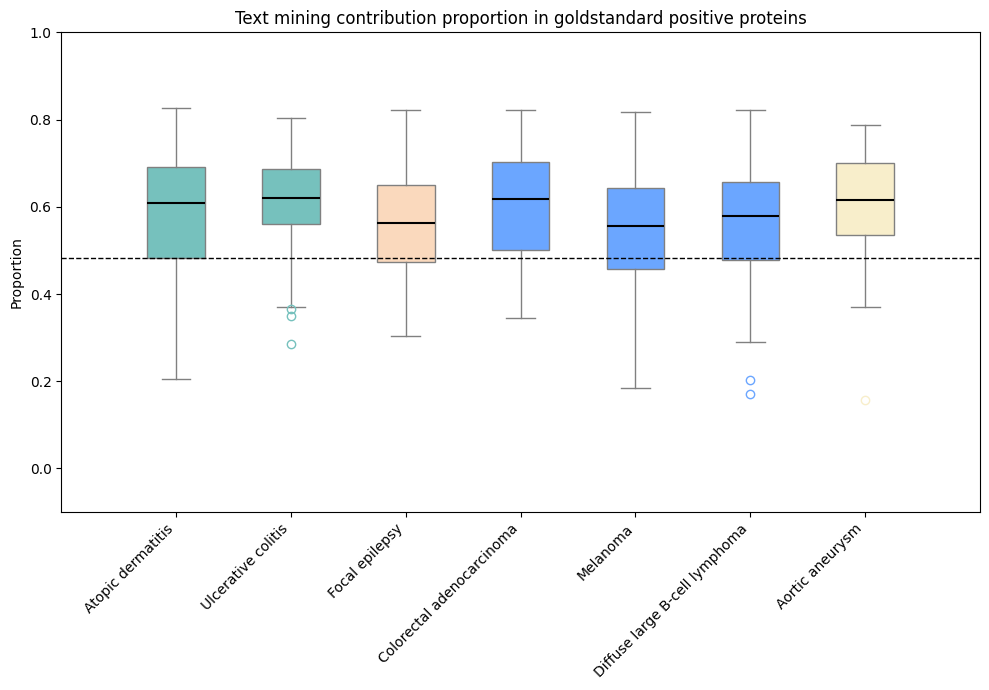

In [4]:
no_text_scores_sum = {k: sum(v)/2 for k, v in no_text_scores.items()}
combined_scores_sum = {k: sum(v)/2 for k, v in combined_scores.items()}

text_ratio = dict()
for k, no_test_score in no_text_scores_sum.items():
    combined_score = combined_scores_sum[k]
    text_ratio[k] = (combined_score - no_test_score) / combined_score
    


disease_text_ratio = dict()

for disease in disease2color.keys():
    file = f'data/test/{disease}.gold_standard.balanced.tsv'
    df_gold_standard = pd.read_csv(file, sep='\t', header=None)
    pos_proteins = df_gold_standard[df_gold_standard.iloc[:,1] == 1].iloc[:,0].values
    
    disease_text_ratio[disease] = [v for k, v in text_ratio.items() if k in pos_proteins]




def format_label(disease):
    display = disease.replace('_', ' ').capitalize()
    if 'b-cell' in display:
        display = display.replace('b-cell', 'B-cell')
    return display

def color_boxplot(bp, disease_names, disease2color):
    for i, disease in enumerate(disease_names):
        color = disease2color.get(disease, '#cccccc')
        bp['boxes'][i].set_color(color)
        bp['boxes'][i].set_linewidth(1.5)
        bp['medians'][i].set_color('black')
        bp['medians'][i].set_linewidth(1.5)
        for key in ['whiskers', 'caps']:
            bp[key][2*i].set_color(color)
            bp[key][2*i+1].set_color(color)
        bp['fliers'][i].set_markeredgecolor(color)

fig, (ax2) = plt.subplots(1, 1, figsize=(10, 7))

disease_names_single = [x for x in disease_text_ratio.keys()]
xlabels_single = [format_label(d) for d in disease_names_single]
bp2 = ax2.boxplot([x for x in disease_text_ratio.values()], patch_artist=True)
for i, disease in enumerate(disease_names_single):
    c = disease2color.get(disease, '#cccccc')
    bp2['boxes'][i].set_facecolor(c)
    bp2['boxes'][i].set_edgecolor('grey')
    bp2['medians'][i].set_color('black')
    bp2['medians'][i].set_linewidth(1.5)
    for key in ['whiskers', 'caps']:
        bp2[key][2*i].set_color('grey')
        bp2[key][2*i+1].set_color('grey')
    bp2['fliers'][i].set_markeredgecolor(c)
ax2.hlines([0.483], 0, len(disease_text_ratio)+1, colors='k', linestyles='dashed', linewidth=1)
ax2.set_xticks(range(1, len(disease_text_ratio)+1))
ax2.set_xticklabels(xlabels_single, rotation=45, ha='right')
ax2.set_ylabel('Proportion')
ax2.set_xlim(0, len(disease_text_ratio)+1)
ax2.set_ylim(-0.1, 1)
ax2.set_title('Text mining contribution proportion in goldstandard positive proteins')
plt.tight_layout()
plt.savefig('results/supp_figures/fig.s4.text_contribution_proportion_in_gold_standard_proteins.png', dpi=300)
plt.show()